## Name :  Olubunmi Adeniran
## ID:    12211718

# Question 1: Plotting Signals



In [23]:
# Importing the necessay libraries
# i have done at the end to make the code stucture bit easier and avoid the repetition module importing

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import dpss
from scipy.signal.windows import hann
from scipy.io.wavfile import read
import sounddevice as sd
from scipy.io.wavfile import write
from numpy.fft import fft, ifft, fftshift
from scipy.signal import convolve
from scipy.io import wavfile



In [24]:
# makin a plot_time function for the signal in time domain

In [25]:
def plot_time(x, fs):
    #time axix
    t_x = np.linspace(0, len(x) / fs, num=len(x), endpoint=False)
    
    plt.figure(figsize=(10, 4))
    plt.plot(t_x, x)
    plt.title("Time Domain Signal")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

# sampling frequency 
fs = 50  
# Duration length of the signal in seconds
duration = 5 
t_x = np.linspace(0, duration, int(fs * duration), endpoint=False)  
x = np.sin(2 * np.pi * 5 * t_x)

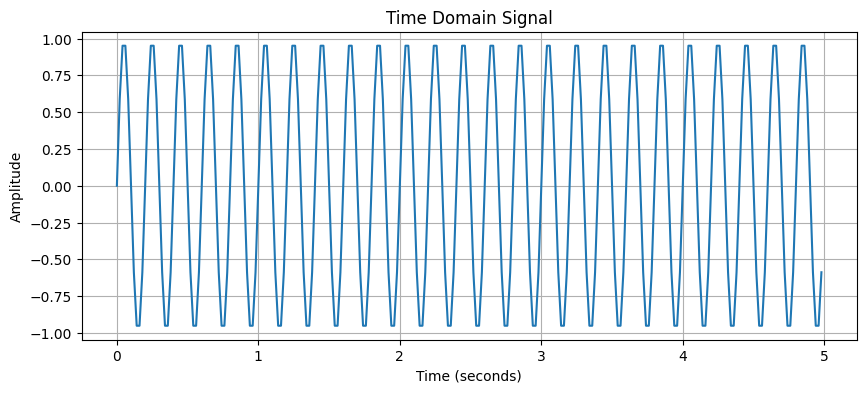

In [26]:
# Below is the plot of signal with 5hz and sampling frequency of 50 
plot_time(x, fs)

## Question 1b

In [27]:
# Plotting Frequencies for this i have to create the plot_freq function

In [28]:
def plot_freq(X, fs):
    n = len(X)
    
    freq = np.fft.fftshift(np.fft.fftfreq(n, d=1/fs))
    # Array shifting 
    X_shifted = np.fft.fftshift(X)
    amplitude = np.abs(X_shifted)
    phase = np.angle(X_shifted)
    
    # adding the threshold
    threshold=1e-5
    phase[amplitude < threshold] = 0
    # creating object for the subplots like fig object and the axes objects
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(freq, amplitude)
    # title of the graph
    ax1.set_title("Amplitude Spectrum")
    # x labels of the graph
    ax1.set_xlabel("Frequency (Hz)")
    # y labels of the graph
    ax1.set_ylabel("Amplitude")
    ax1.grid(True)
    
    ax2.plot(freq, phase)
    ax2.set_title("Phase Spectrum")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Phase (radians)")
    ax2.grid(True)
    plt.show()

# sampling frequency
fs = 50
# time axis vector
t = np.linspace(0, 5, int(5 * fs), endpoint=False) 
x = np.sin(2 * np.pi * 5 * t)

# the DFT of the signal
X = np.fft.fft(x)


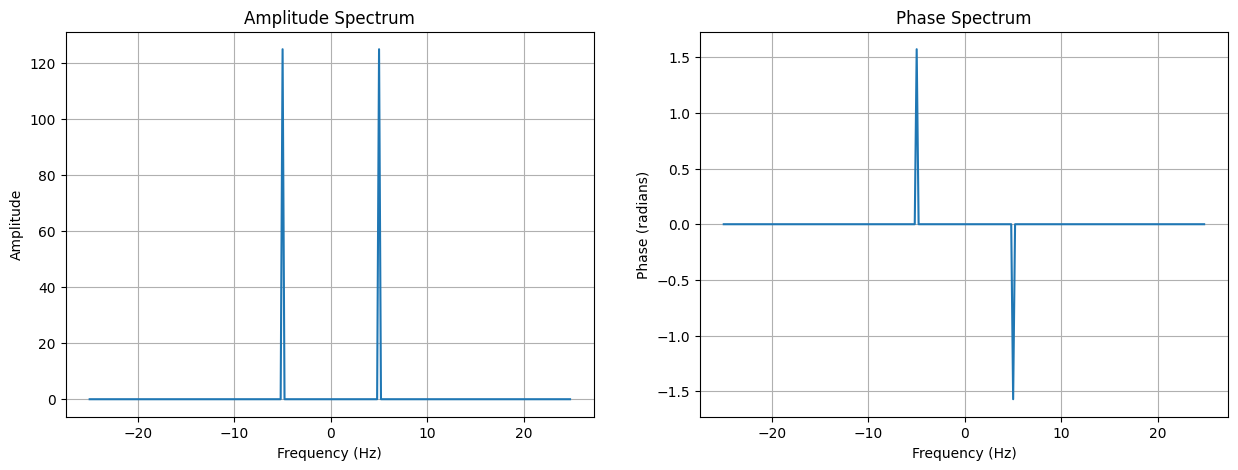

In [29]:
plot_freq(X, fs)

## Question 2


In [30]:
def psd(x, w, fs):
    #implementation of psd function
    N = len(x)
    x_w = x * w
    X = np.fft.fft(x_w)
    # Sum of the squared window values
    S = np.sum(w ** 2)  
    freqs = np.fft.fftfreq(N, d=1/fs)
    pos_freqs = freqs[freqs >= 0]
    psd_vals = 2 * (np.abs(X[freqs >= 0]) ** 2) / (fs * S)
    
    return pos_freqs, psd_vals

# Question 2b

- **Observations**

For verifying the **orthognality** i have compute the dot products of each tapers

- if the dot product valus is 0 or close to zero it means they are orthognal.
- The matrix below shows the dot product results 
- the diagonal values are the utself dot product that is why it is 1

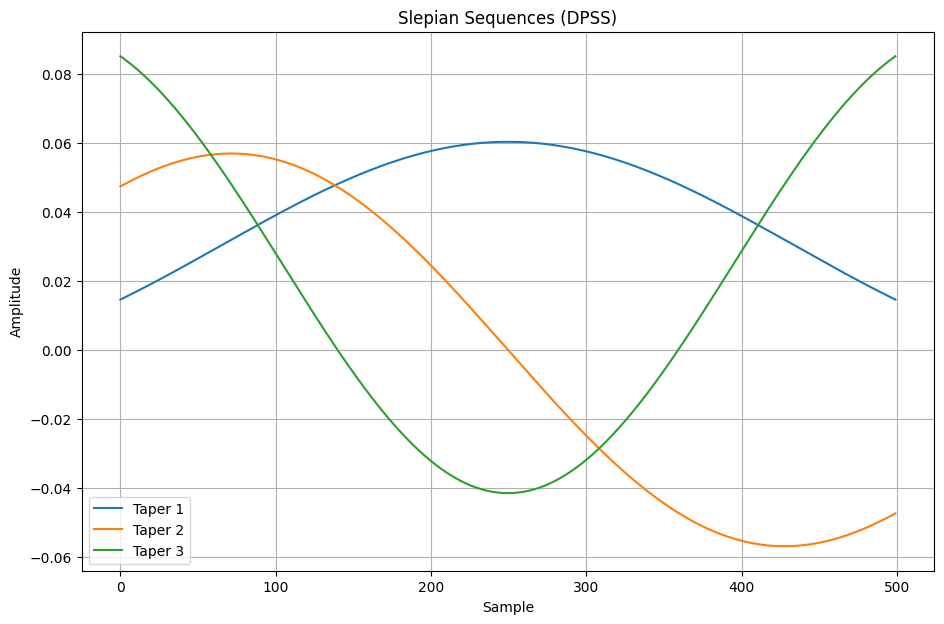

Orthogonality matrix:
 [[ 1.00000000e+00  3.33934269e-17  1.45283091e-17]
 [ 3.33934269e-17  1.00000000e+00 -6.93889390e-18]
 [ 1.45283091e-17 -6.93889390e-18  1.00000000e+00]]


In [31]:
# plotting based on the requirements that are mentioned in the questions
M = 500  # Length of the taper
NW = 1  # Time-bandwidth parameter
tapers = dpss(M, NW, Kmax=3)


plt.figure(figsize=(11, 7))
for i, taper in enumerate(tapers):
    #plotting the each tapper with for loop
    plt.plot(taper, label=f"Taper {i+1}")
plt.legend()
plt.title("Slepian Sequences (DPSS)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Verify orthogonality
orthogonality = np.array([[np.dot(t1, t2) for t2 in tapers] for t1 in tapers])
print("Orthogonality matrix:\n", orthogonality)


## Question 2C

In [32]:
def multitaper(x, fs, k):
    # Implement a multipaper function using the dpss function from the definition
    N = len(x)
    NW = N / fs 
    tapers = dpss(N, NW, Kmax=k)
    
    # computing the psd of each taper and then computing the mean of the values
    psd_list = []
    for taper in tapers:
        f, psd_vals = psd(x, taper, fs)
        psd_list.append(psd_vals)
    # takinf the mean
    multitaper_psd = np.mean(psd_list, axis=0)  
    return f, multitaper_psd


Sampling frequency: 16000 Hz


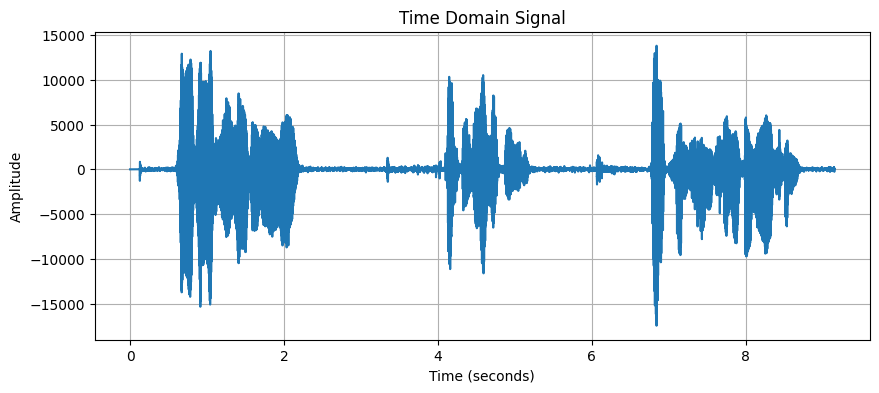

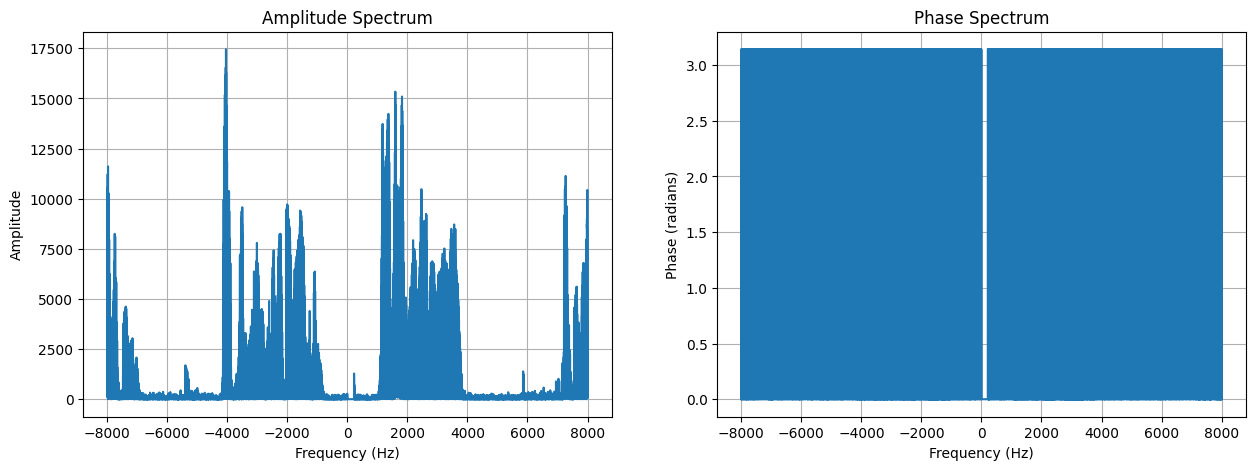

In [33]:
import scipy.io.wavfile as wavfile
import numpy as np
import matplotlib.pyplot as plt
# Real life example(provided in the question document)
fs, signal = wavfile.read('speech.wav')
print(f"Sampling frequency: {fs} Hz")

if len(signal.shape) == 2:
    signal = signal.mean(axis=1)

# Plot the signal in the time domain
plot_time(signal, fs)

# Plot the signal in the frequency domain
plot_freq(signal, fs)



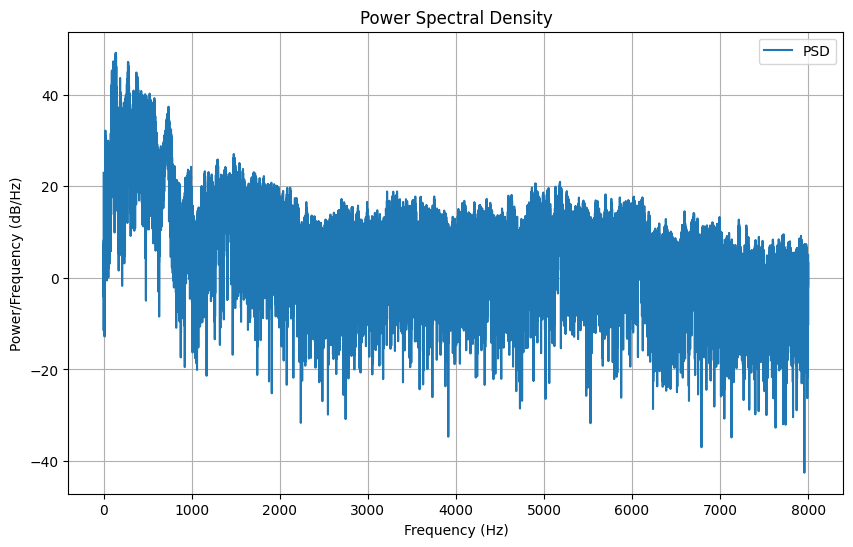

In [34]:
# Compute and plot the PSD
N = len(signal)
 # Use Hanning window
window = np.hanning(N) 
frequencies, psd_values = psd(signal, window, fs)

plt.figure(figsize=(10, 6))
plt.plot(frequencies, 10 * np.log10(psd_values), label="PSD")
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid()
plt.legend()
plt.show()

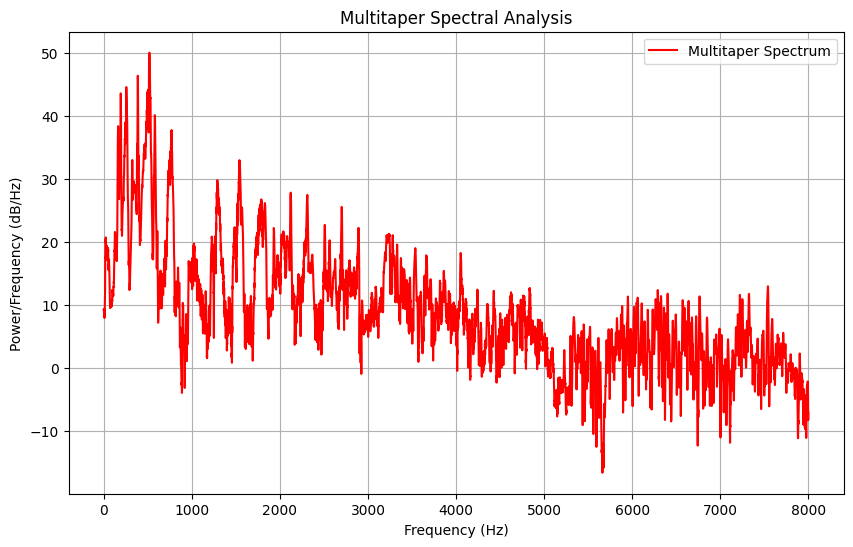

In [35]:
# compute and plot the multitaper spectrum using 20 tapers
frequencies, multitaper_values = multitaper(signal, fs, k=20)

# plotting
plt.figure(figsize=(10, 6))
plt.plot(frequencies, 10 * np.log10(multitaper_values), label="Multitaper Spectrum", color='r')
plt.title("Multitaper Spectral Analysis")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid()
plt.legend()
plt.show()


# Question 3

In [36]:
# function for the short time fourier transform
def stft(x, fs, wlen, win_func=False):

    N = len(x)
    # samples for each window
    window_length = int(fs * wlen)  
    # total number of windows
    n_windows = N // window_length 
    # frequency and time arrays
    freqs = np.fft.fftfreq(window_length, d=1/fs)[:window_length//2 + 1]
    times = np.arange(0, n_windows) * wlen
    
    # hann window functionality
    if win_func:
        window = hann(window_length)
    else:
        window = np.ones(window_length)

    stft_matrix = []
    # loop over all the windows 
    for i in range(n_windows):
        segment = x[i * window_length : (i + 1) * window_length]
        # Ensure all segments are same length
        if len(segment) < window_length:  
            break
        # Apply window function
        segment = segment * window  
        # Positive frequencies only
        spectrum = np.fft.fft(segment)[:window_length//2 + 1]  
        stft_matrix.append(spectrum)
    # Transpose for correct shape
    stft_matrix = np.array(stft_matrix).T  
    return stft_matrix, freqs, times


# Question 3b

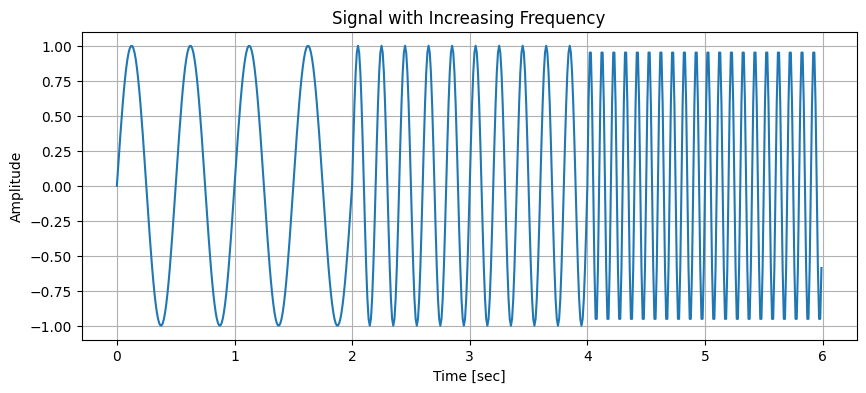

In [37]:
# recreating the signal given in the assignment, the signal should be increasing frequency 
# Define the signal
fs = 100  # Sampling frequency
t = np.arange(0, 6, 1/fs)  # Time vector from 0 to 6 seconds
signal = np.piecewise(t, 
                      [t < 2, (t >= 2) & (t < 4), t >= 4],
                      [lambda t: np.sin(2 * np.pi * 2 * t),  
                       lambda t: np.sin(2 * np.pi * 5 * t),  
                       lambda t: np.sin(2 * np.pi * 10 * t)])

# Plot the signal in the time domain
plt.figure(figsize=(10, 4))
plt.plot(t, signal)
plt.title("Signal with Increasing Frequency")
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


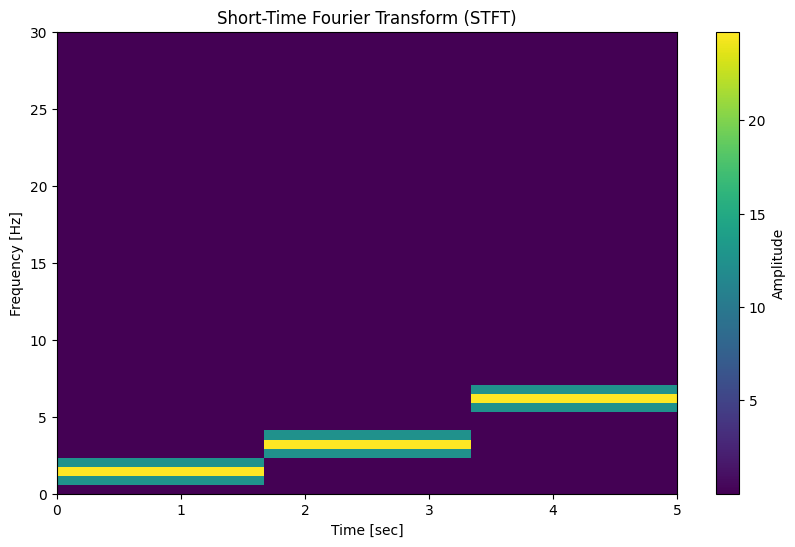

In [38]:
# plotting the colormap with stft
def plot_colormap_stft(stft_matrix, fs, times, freqs, fmax=None, log=False, colormap_min=None, colormap_max=None):

    magnitude = np.abs(stft_matrix)
    if log:
        # Avoid log(0)
        magnitude = np.log(magnitude + 1e-10)  
    
    plt.figure(figsize=(10, 6))
    extent = [times[0], times[-1], freqs[0], fmax or freqs[-1]]
    plt.imshow(magnitude, aspect='auto', origin='lower', extent=extent, vmin=colormap_min, vmax=colormap_max)
    plt.colorbar(label="Amplitude")
    plt.title("Short-Time Fourier Transform (STFT)")
    plt.xlabel("Time [sec]")
    plt.ylabel("Frequency [Hz]")
    plt.show()

# Compute the STFT
wlen = 1.0  # Window length in seconds
stft_matrix, freqs, times = stft(signal, fs, wlen, win_func=True)

# Plot the STFT
plot_colormap_stft(stft_matrix, fs, times, freqs, fmax=30)


## Question 3C

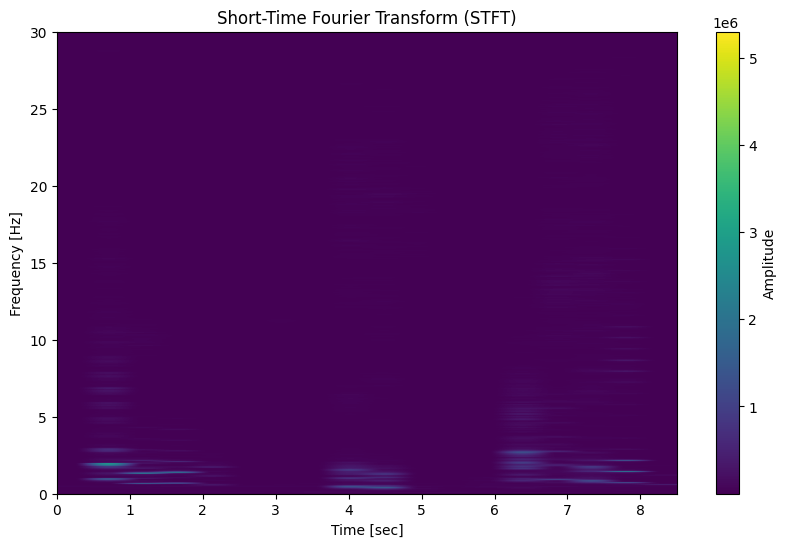

In [39]:
# Load the audio file
fs, speech_signal = read('speech.wav')

# Convert to mono if stereo
if len(speech_signal.shape) == 2:
    speech_signal = speech_signal.mean(axis=1)

# Compute the STFT
wlen = 0.5  # Window length in seconds
stft_matrix, freqs, times = stft(speech_signal, fs, wlen, win_func=True)
# print(stft_matrix)
# Plot the STFT with suitable fmax
plot_colormap_stft(stft_matrix, fs, times, freqs, fmax=30)


## observation

In [40]:
''' We can observe by seeing the variation of the cluster which forms by change in the voice level of each individual
    means A person who speaks with the higher voice has higher harmonics and the frequency and it will be visible as the band will shift upward in frequency 
    as you can see in the graph above from this you have a visible cluseters of enrgy bands for different voices frequencies and voice level
'''


' We can observe by seeing the variation of the cluster which forms by change in the voice level of each individual\n    means A person who speaks with the higher voice has higher harmonics and the frequency and it will be visible as the band will shift upward in frequency \n    as you can see in the graph above from this you have a visible cluseters of enrgy bands for different voices frequencies and voice level\n'

# Question 4a

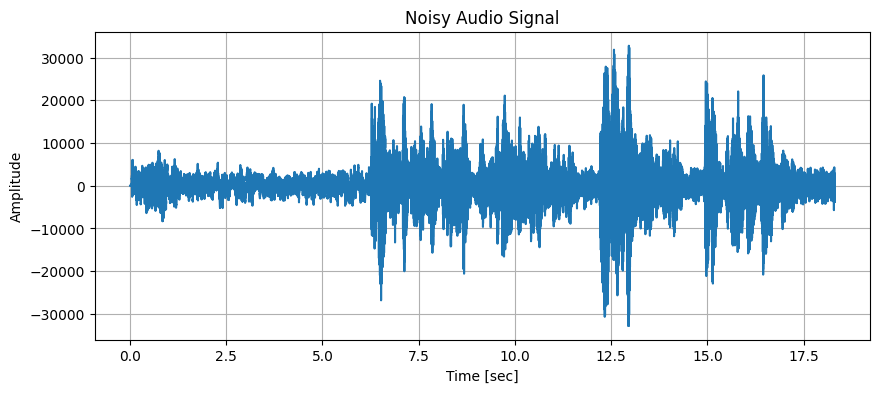

In [41]:
# Load the noisy audio file
fs, noisy_signal = read("noisy.wav")

# Convert to mono if stereo
if len(noisy_signal.shape) == 2:
    noisy_signal = noisy_signal.mean(axis=1)

# Play the noisy audio
sd.play(noisy_signal, fs)

# Time vector
t = np.linspace(0, len(noisy_signal) / fs, len(noisy_signal))

# Plot the noisy signal in the time domain
plt.figure(figsize=(10, 4))
plt.plot(t, noisy_signal)
plt.title("Noisy Audio Signal")
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


## Question 4B

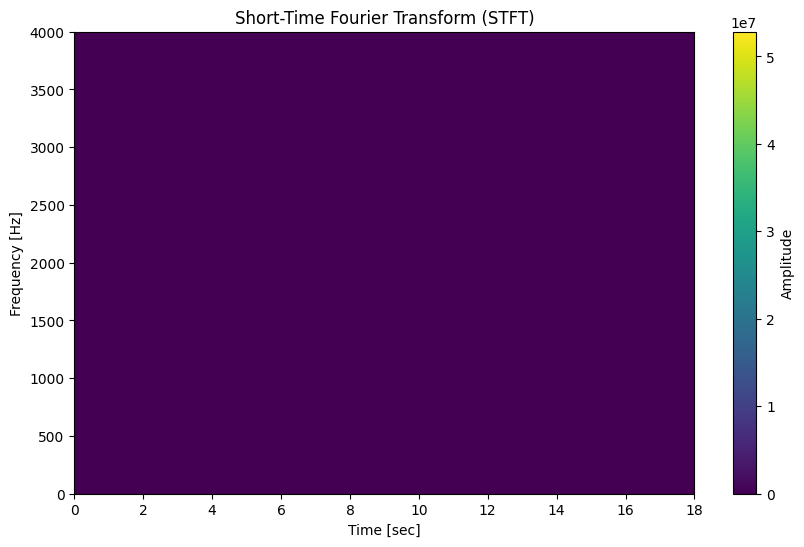

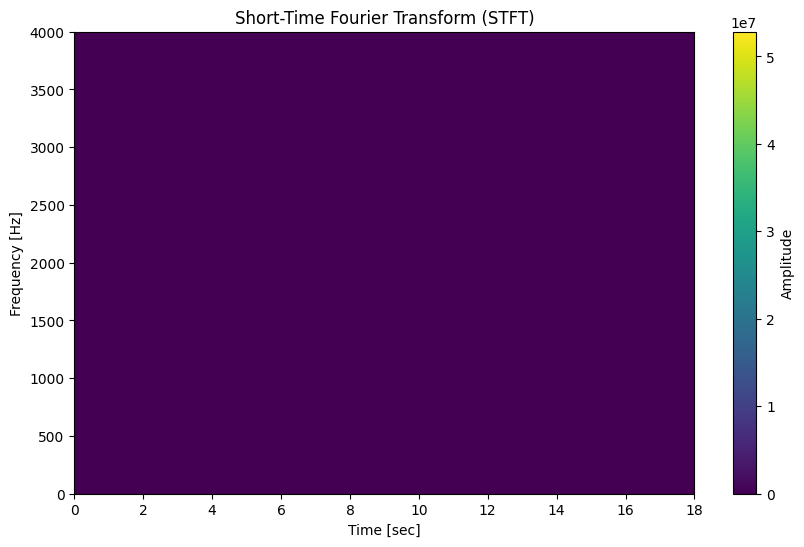

Frequency resolution: 5.0 Hz


In [42]:
wlen = 0.2  # Window length in seconds
window_length = int(fs * wlen)

# STFT with estimated(rectangular) window
stft_rect, freqs, times = stft(noisy_signal, fs, wlen, win_func=False)

# STFT with Hann window
stft_hann, freqs, times = stft(noisy_signal, fs, wlen, win_func=True)

# Maximum amplitude for consistent color scale
max_amplitude = max(np.abs(stft_rect).max(), np.abs(stft_hann).max())

# Plot STFT with rectangular window
plot_colormap_stft(stft_rect, fs, times, freqs, fmax=4000, log=True, colormap_min=0, colormap_max=max_amplitude)

# Plot STFT with Hann window
plot_colormap_stft(stft_hann, fs, times, freqs, fmax=4000, log=True, colormap_min=0, colormap_max=max_amplitude)

# Frequency resolution
frequency_resolution = fs / window_length
print(f"Frequency resolution: {frequency_resolution} Hz")


## Question 4C

In [43]:
def noise_gate(W, fs, t_noise, c_thresh):
    # Calculate number of indices that represent t_noise seconds of data
    noise_idx = int(t_noise * fs / window_length)
    
    # Extract the noise matrix from the first few seconds
    noise_matrix = W[:, :noise_idx]
    
    # Compute the log-scaled amplitudes
    log_amplitude = np.log(np.abs(noise_matrix) + 1e-10)
    
    # Calculate the mean and std deviation of the log-scaled amplitudes
    mu = np.mean(log_amplitude, axis=1)
    sigma = np.std(log_amplitude, axis=1)
    
    # Compute the threshold for each frequency bin
    thresh = mu[:, np.newaxis] + c_thresh * sigma[:, np.newaxis]
    
    # Apply the noise gate threshold
    log_W = np.log(np.abs(W) + 1e-10)
    W_clean = np.where(log_W >= thresh, W, 0)
    
    return W_clean

# Adjust the call to your noise gate function
W_clean_est = noise_gate(stft_rect, fs, t_noise=5, c_thresh=3)
W_clean_hann = noise_gate(stft_hann, fs, t_noise=5, c_thresh=3)


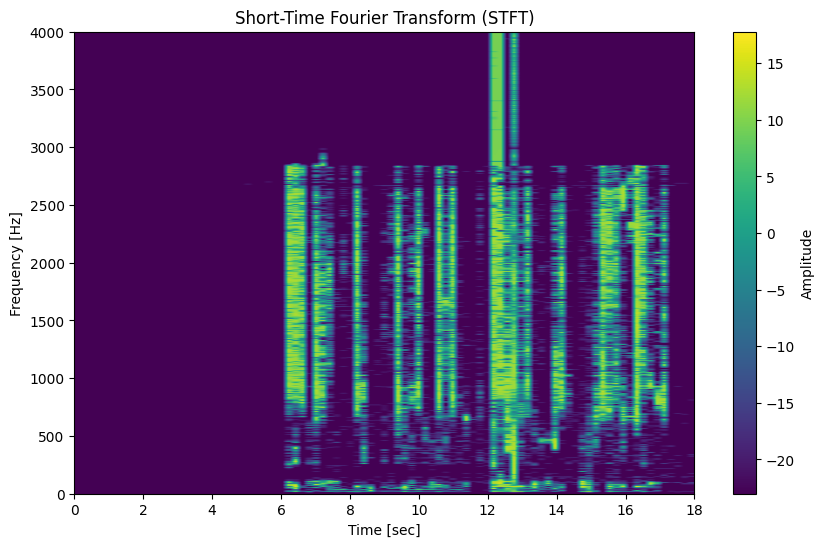

In [44]:
plot_colormap_stft(W_clean_est, fs, times, freqs, fmax=4000, log=True)

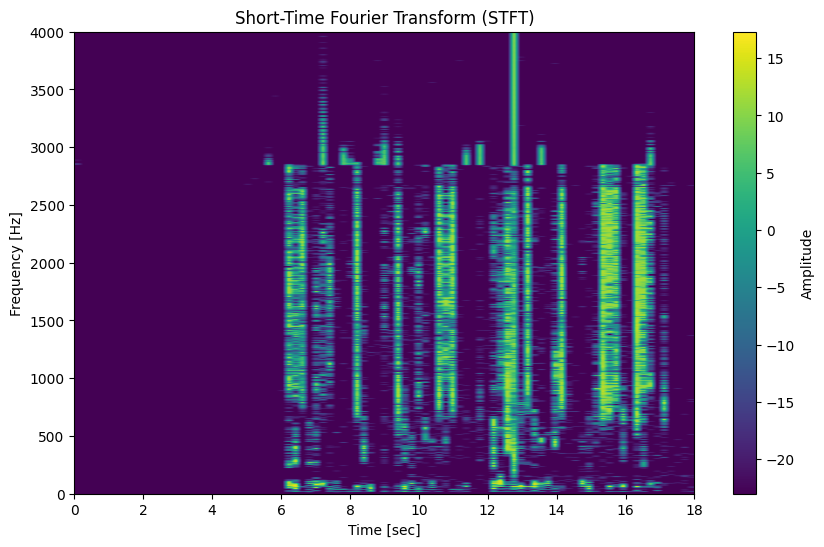

In [45]:
plot_colormap_stft(W_clean_hann, fs, times, freqs, fmax=4000, log=True)

# Question 4D

In [46]:
def istft(X_stft):
    n_freqs, n_windows = X_stft.shape
    # Recover original window length: (n_freqs - 1) * 2
    window_length = (n_freqs - 1) * 2
    # Each STFT column is a separate frame of length `window_length`.
    signal_length = n_windows * window_length
    x_reconstructed = np.zeros(signal_length)

    # Reconstruct each time-frame by inverse FFT
    for i in range(n_windows):
        # We mirror them (excluding the very top bin) to get negative frequencies
        full_spectrum = np.concatenate([
            X_stft[:, i],
            np.conj(X_stft[-2:0:-1, i])  # Exclude DC (index=0) and Nyquist (last index)
        ])
        time_segment = np.fft.ifft(full_spectrum).real
        x_reconstructed[i * window_length: (i + 1) * window_length] += time_segment
    
    return x_reconstructed




In [64]:
# Rectangular window vector
z_clean_rect = istft(W_clean_est)
# Hann window vector
z_clean_hann = istft(W_clean_hann)


Playing cleaned audio (Rectangular Window):
Playing cleaned audio (Hann Window):


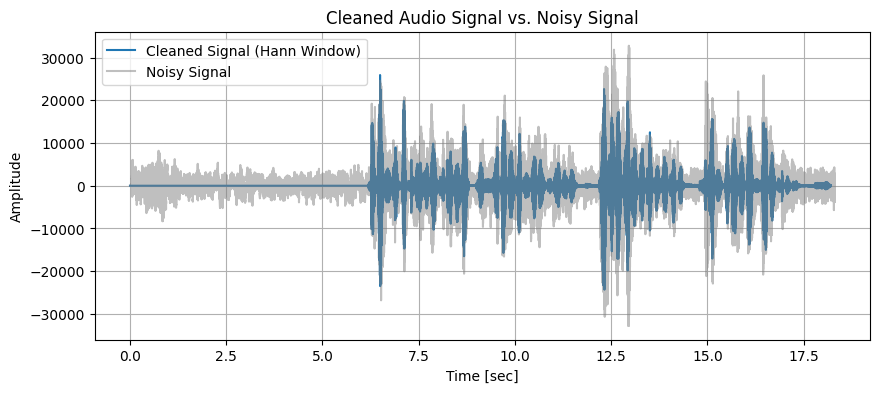

In [ ]:
# scale signals to 16-bit integer range
z_clean_rect_16bit = np.int16(z_clean_rect / np.max(np.abs(z_clean_rect)) * 32767)
z_clean_hann_16bit = np.int16(z_clean_hann / np.max(np.abs(z_clean_hann)) * 32767)

# save cleaned audio to disk
write("cleaned_rect.wav", fs, z_clean_rect_16bit)
write("cleaned_hann.wav", fs, z_clean_hann_16bit)

# 4) Play the cleaned audio (optional listening test)
print("Playing cleaned audio (Rectangular Window):")
sd.play(z_clean_rect_16bit, fs)
sd.wait()

print("Playing cleaned audio (Hann Window):")
sd.play(z_clean_hann_16bit, fs)
sd.wait()

# 5) Plot the cleaned audio signals in time domain vs the original noisy signal
#    (Here we'll plot the Hann-window version as an example.)
t_clean_hann = np.linspace(0, len(z_clean_hann) / fs, len(z_clean_hann))
t_noisy = np.linspace(0, len(noisy_signal) / fs, len(noisy_signal))

plt.figure(figsize=(10, 4))
plt.plot(t_clean_hann, z_clean_hann, label="Cleaned Signal (Hann Window)")
plt.plot(t_noisy, noisy_signal, alpha=0.5, label="Noisy Signal", color='gray')
plt.title("Cleaned Audio Signal vs. Noisy Signal")
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

## Question 5

In [49]:
def ideal_lowpass(fc, fs, M):

    # Frequency resolution
    freq_res = fs / M
    f = np.linspace(-fs / 2, fs / 2, M)
    
    # Define amplitude spectrum
    H_0 = np.where(np.abs(f) <= fc, 1, 0)
    
    # Compute impulse response using inverse FFT
    h_0 = fftshift(np.real(ifft(fftshift(H_0))))
    
    return H_0, h_0

In [50]:
def hann_window(M):
    n = np.arange(M)
    w = 0.5 - 0.5 * np.cos(2 * np.pi * n / (M - 1))
    return w


In [51]:
def fir_lowpass(fc, fs, M):

    # Design ideal low-pass filter
    H0, h0 = ideal_lowpass(fc, fs, M)
    
    # Generate Hann window
    w_hann = hann_window(M)
    
    # Multiply ideal impulse response with window
    h_fir = h0 * w_hann
    
    # Compute amplitude spectrum
    H_fir = fftshift(np.abs(fft(h_fir)))
    
    return H_fir, h_fir


Comments on the Graphs

- The tails of the Impulse response using the hann window gets zero, means it becomes flat
- and in the time domain as you can see there is no flat line we have highs and lows curves

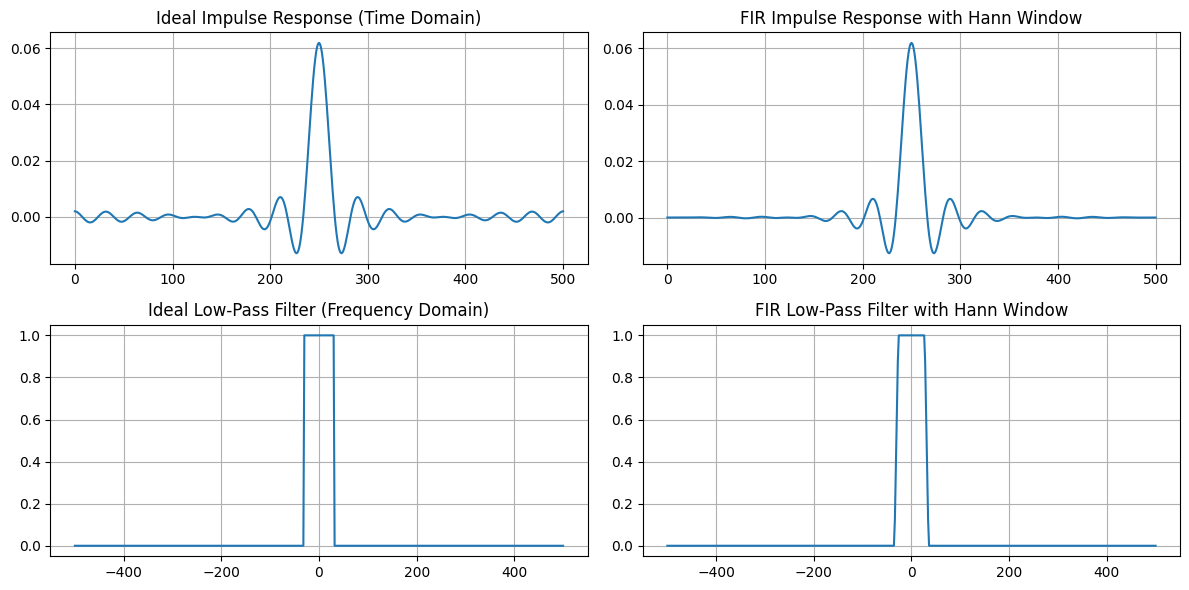

In [52]:
# Parameters as per question
M = 501  # Filter length
fc = 30  # Cut-off frequency
fs = 1000  # Sampling frequency

# Design filters
H_0, h_0 = ideal_lowpass(fc, fs, M)
H_fir, h_fir = fir_lowpass(fc, fs, M)

# Plot impulse responses
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(h_0, label="Ideal Impulse Response")
plt.title("Ideal Impulse Response (Time Domain)")
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(h_fir, label="FIR Impulse Response")
plt.title("FIR Impulse Response with Hann Window")
plt.grid()

# Plot amplitude spectra
frequencies = np.linspace(-fs/2, fs/2, M)
plt.subplot(2, 2, 3)
plt.plot(frequencies, H_0, label="Ideal Filter")
plt.title("Ideal Low-Pass Filter (Frequency Domain)")
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(frequencies, H_fir, label="FIR Filter")
plt.title("FIR Low-Pass Filter with Hann Window")
plt.grid()
plt.tight_layout()
plt.show()


## Question 5b 

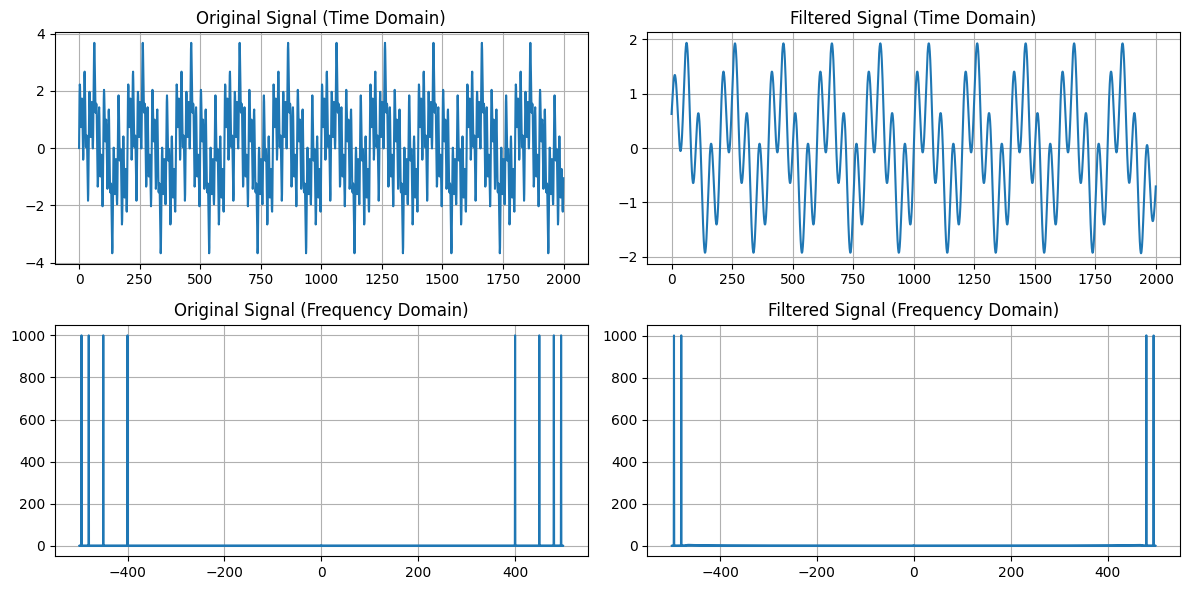

In [53]:
# Define multi-frequency signal
fs = 1000  # Sampling frequency
N = 2000  # Signal length
n = np.arange(N)
x = (np.sin(2 * np.pi * 5 * n / fs) + 
     np.sin(2 * np.pi * 20 * n / fs) +
     np.sin(2 * np.pi * 50 * n / fs) +
     np.sin(2 * np.pi * 100 * n / fs))

# Apply FIR filter using convolution
h_fir = fir_lowpass(fc=30, fs=fs, M=501)[1]
x_filt = np.convolve(x, h_fir, mode='same')

# Plot time and frequency domains
frequencies = np.fft.fftfreq(N, 1/fs)
X = np.fft.fft(x)
X_filt = np.fft.fft(x_filt)
# plotting with the subplots mkaing a canvas of 2X2
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(n, x)
plt.title("Original Signal (Time Domain)")
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(n, x_filt)
plt.title("Filtered Signal (Time Domain)")
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(frequencies, np.abs(np.fft.fftshift(X)))
plt.title("Original Signal (Frequency Domain)")
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(frequencies, np.abs(np.fft.fftshift(X_filt)))
plt.title("Filtered Signal (Frequency Domain)")
plt.grid()
plt.tight_layout()
plt.show()


# Question 5C

In [54]:
# Function to read and preprocess the audio signal
def load_audio(filename):
    fs, audio = wavfile.read(filename)
    if audio.ndim > 1:  # Convert stereo to mono by averaging the two channels
        audio = audio.mean(axis=1)
    return fs, audio

# Function to play audio
def play_audio(audio, sampling_rate):
    sd.play(audio, sampling_rate)
    sd.wait()

# plotting

In [55]:
# Function to plot audio signals
def plot_signal(signal, fs, title):
    times = np.arange(len(signal)) / fs
    plt.figure(figsize=(10, 4))
    plt.plot(times, signal)
    plt.title(title)
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()


# Naively downsample the audio signal

In [56]:
# Naive downsampling function
def naive_downsample(audio, down_factor):
    return audio[::down_factor]


In [58]:
# FIR filtering and downsampling function
def fir_downsample(audio, h_fir, down_factor):
    filtered_audio = convolve(audio, h_fir, mode='same')
    return filtered_audio[::down_factor]


In [59]:
# Load the audio file
filename = 'beethoven.wav'
sampling_rate, audio_signal = load_audio(filename)
print(f"Original sampling rate: {sampling_rate} Hz")
print(f"Original length: {len(audio_signal)} samples, {len(audio_signal) / sampling_rate:.2f} seconds")


Original sampling rate: 44100 Hz
Original length: 1339392 samples, 30.37 seconds


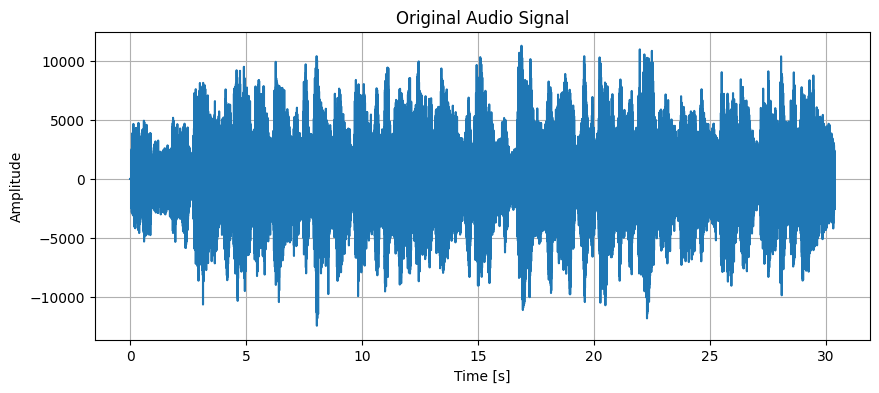

In [60]:
# Play the original audio signal
play_audio(audio_signal, sampling_rate)

# Plot the original audio signal
plot_signal(audio_signal, sampling_rate, "Original Audio Signal")


Naive - Sampling rate: 8820.0 Hz, Length: 267879 samples, 30.37 seconds
FIR - Sampling rate: 8820.0 Hz, Length: 267879 samples, 30.37 seconds


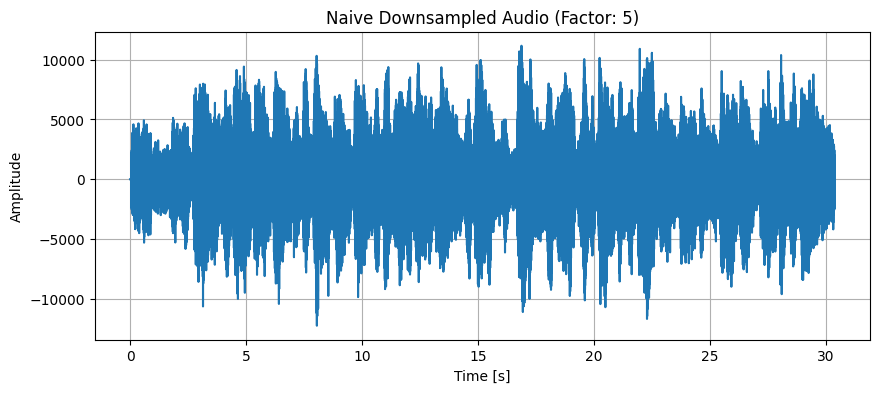

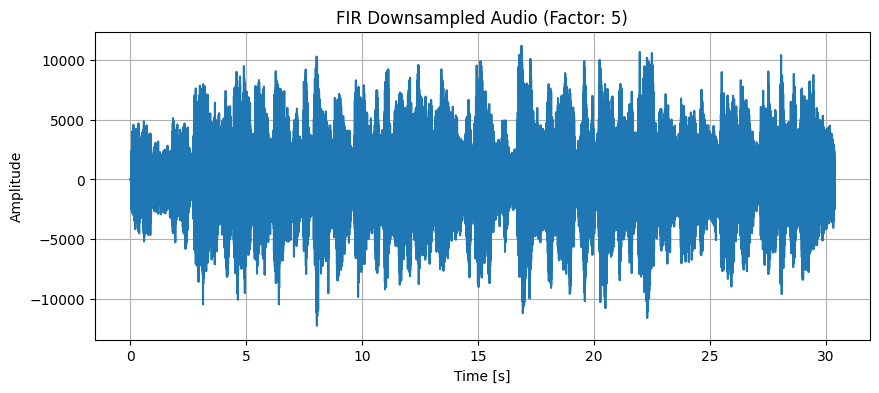

Naive - Sampling rate: 4410.0 Hz, Length: 133940 samples, 30.37 seconds
FIR - Sampling rate: 4410.0 Hz, Length: 133940 samples, 30.37 seconds


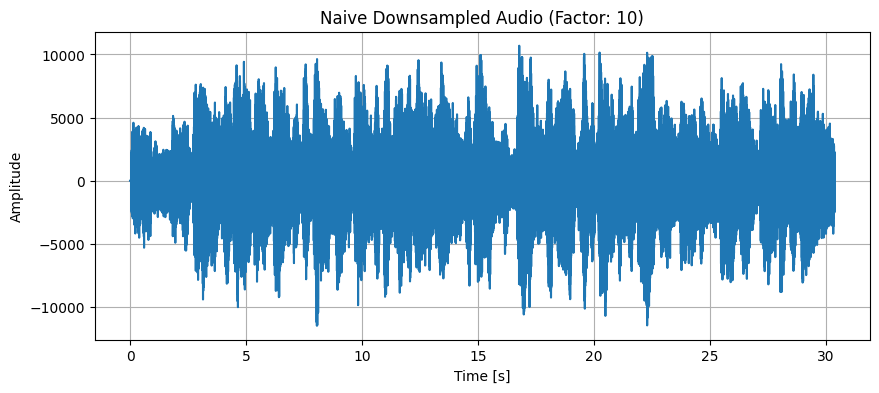

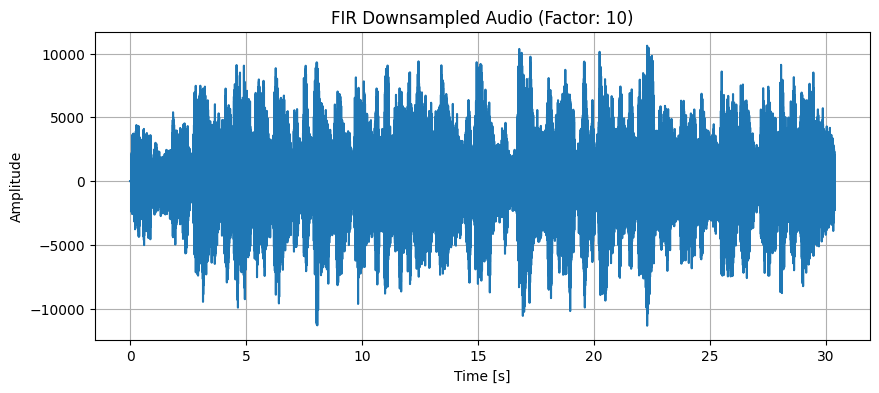

Naive - Sampling rate: 2205.0 Hz, Length: 66970 samples, 30.37 seconds
FIR - Sampling rate: 2205.0 Hz, Length: 66970 samples, 30.37 seconds


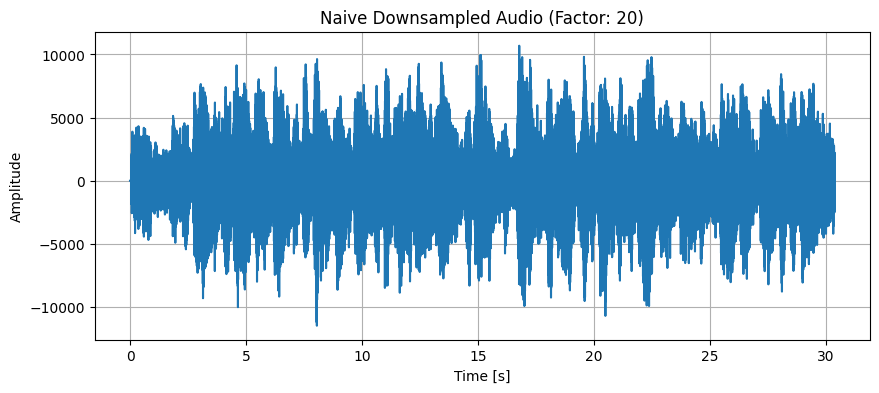

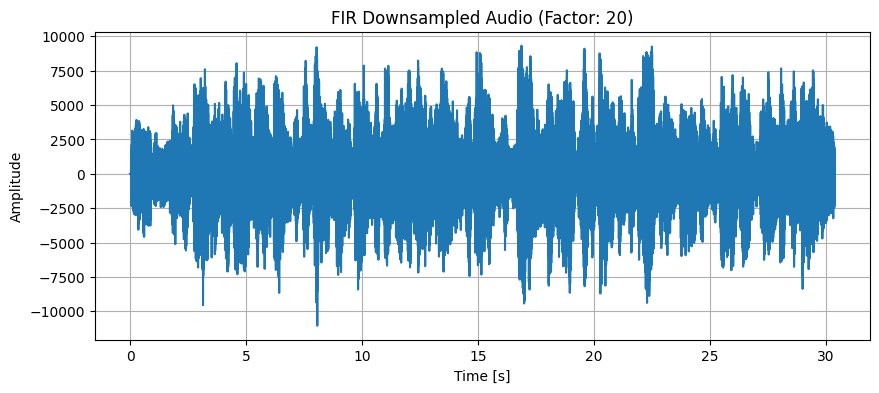

In [ ]:
# Specify downsampling factors
down_factors = [5, 10, 20]

for cdown in down_factors:
    fs_down = sampling_rate / cdown
    fc = fs_down / 2

    # Use FIR low-pass filter
    h_fir = fir_lowpass(fc, sampling_rate, 501)[1]
    # Naive downsampling
    audio_naive = naive_downsample(audio_signal, cdown)
    print(f"Naive - Sampling rate: {fs_down} Hz, Length: {len(audio_naive)} samples, {len(audio_naive) / fs_down:.2f} seconds")
    # Play naively downsampled audio
    play_audio(audio_naive / 2, fs_down)  # Divide by 2 to prevent clipping
    # FIR filter then downsample
    audio_fir = fir_downsample(audio_signal, h_fir, cdown)
    print(f"FIR - Sampling rate: {fs_down} Hz, Length: {len(audio_fir)} samples, {len(audio_fir) / fs_down:.2f} seconds")
    # playing FIR downsampled audio
    play_audio(audio_fir / 2, fs_down)  # Divide by 2 to prevent clipping
    # Plot the audio signals
    plot_signal(audio_naive, fs_down, f"Naive Downsampled Audio (Factor: {cdown})")
    plot_signal(audio_fir, fs_down, f"FIR Downsampled Audio (Factor: {cdown})")


In [62]:
'''
In the Naive Sampling there is a less distortion becuase the reduction is moderate in the sampling rate of the sound 
and it allows to presve the original signal, altiugh it is little noisey as well

For the FIR downsampling it is observed that there is also a less distorion and it keep tried to retain the original signal and 
add less noise to it

the graohs you can see is made for the differnet factors mentioned in the qurstion
'''

'\nIn the Naive Sampling there is a less distortion becuase the reduction is moderate in the sampling rate of the sound \nand it allows to presve the original signal, altiugh it is little noisey as well\n\nFor the FIR downsampling it is observed that there is also a less distorion and it keep tried to retain the original signal and \nadd less noise to it\n\nthe graohs you can see is made for the differnet factors mentioned in the qurstion\n'